<div align="center">

#  Week 6 – Natural Language Processing (NLP)

## SMS Spam Detection

### 📘 Text Classification using Machine Learning

---

### Objective

Natural Language Processing (NLP) enables computers to understand and process human language.

In this project, we will build a machine learning model capable of classifying SMS messages as **Spam** or **Ham (Not Spam)**.

The project consists of:

- Text Preprocessing
- Feature Extraction
- Machine Learning Classification
- Model Evaluation

</div>

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# Loading the Dataset

The SMS Spam Collection dataset contains text messages labelled as either:

- Ham (Normal Message)
- Spam (Unwanted Message)

This dataset will be used for text classification.

In [24]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [25]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [27]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [28]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

# Keeping Required Columns

The original dataset contains extra columns that are not required.

We will retain only:

- Label
- Message

In [29]:
df = df.iloc[:, :2]

df.columns = ["Label", "Message"]

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Message Distribution

Let's see how many messages belong to each category.

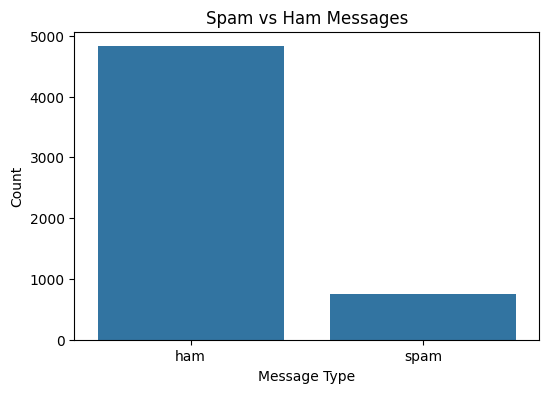

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Label")

plt.title("Spam vs Ham Messages")

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.savefig("Visualizations/message_distribution.png")

plt.show()

# Converting Text to Lowercase

Converting text to lowercase ensures that words like **Free**, **FREE**, and **free** are treated as the same word.

In [31]:
df["Message"] = df["Message"].str.lower()

df.head()

,Label,Message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


# Removing Punctuation

In [32]:
import string

df["Message"] = df["Message"].str.translate(
    str.maketrans("", "", string.punctuation)
)

df.head()

,Label,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [33]:
# removing numbers from the text
df["Message"] = df["Message"].str.replace(r"\d+", "", regex=True)

df.head()

,Label,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [34]:
# removing exra spaces from the text


df["Message"] = df["Message"].str.replace(r"\s+", " ", regex=True).str.strip()

df.head()

,Label,Message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


# 💡 Observation

The text has now been cleaned by:

- Converting to lowercase
- Removing punctuation
- Removing numbers
- Removing extra spaces

The cleaned text is now ready for feature extraction and machine learning.

---

<div align="center">

# Model Building & Evaluation

</div>

## Objective

In this section, we will convert text into numerical features using **TF-IDF**, train a **Multinomial Naive Bayes** classifier, and evaluate its performance using different machine learning metrics.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF imported successfully!")

TF-IDF imported successfully!


#  Converting Text into Numerical Features

Machine learning models cannot understand text directly.

TF-IDF converts words into numerical values based on their importance in the dataset.

In [36]:
tfidf = TfidfVectorizer(stop_words="english")

X = tfidf.fit_transform(df["Message"])

y = df["Label"]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (5572, 8295)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

print("Training and Testing sets created successfully!")

Training and Testing sets created successfully!


# Training Naive Bayes Classifier

We will use the **Multinomial Naive Bayes** algorithm because it performs well on text classification tasks.

In [38]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [39]:
## Predicting test data

predictions = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


# Model Accuracy

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 96.86%


# Classification Report

The report provides:

- Precision
- Recall
- F1-Score
- Support

These metrics help evaluate the model's performance in detail.

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [42]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

cm

array([[965,   0],
       [ 35, 115]])

# Visualizing Confusion Matrix

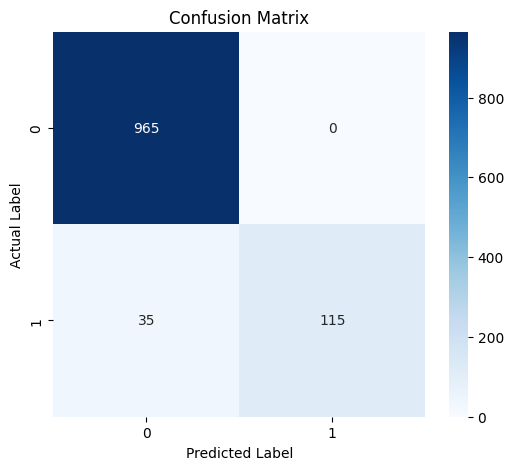

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.savefig("Visualizations/confusion_matrix.png")

plt.show()

#  Testing the Model with Custom Messages

Let's test the trained model using a few custom SMS messages.

In [44]:
sample_messages = [

    "Congratulations! You have won a free iPhone.",

    "Are we still meeting tomorrow?",

    "Claim your cash prize now!",

    "Don't forget to bring your assignment."

]

sample_features = tfidf.transform(sample_messages)

sample_predictions = model.predict(sample_features)

results = pd.DataFrame({

    "Message": sample_messages,

    "Prediction": sample_predictions

})

results

,Message,Prediction
0,Congratulations! You have won a free iPhone.,spam
1,Are we still meeting tomorrow?,ham
2,Claim your cash prize now!,spam
3,Don't forget to bring your assignment.,ham


#  Observation

The model successfully classifies SMS messages into:

- Spam
- Ham

The high accuracy demonstrates that TF-IDF combined with Naive Bayes is an effective approach for spam detection.

# Conclusion

During this project, we successfully developed an SMS Spam Detection model using Natural Language Processing.

The following tasks were completed:

- Loaded and explored the dataset
- Cleaned and preprocessed text
- Converted text into numerical features using TF-IDF
- Trained a Multinomial Naive Bayes classifier
- Evaluated the model using accuracy, classification report, and confusion matrix
- Tested the model using custom SMS messages

This project demonstrates how NLP and Machine Learning can automatically identify spam messages and assist in filtering unwanted communication.